# Calibrate Benchmark Settings

Uses Optuna (Bayesian optimization) to find simulation parameters for all benchmarks
in `Benchmarking.ipynb`.

**Part A — Nonlinear Difficulty** (Circles, Moons, Swiss Rolls):
- Easy: ARI 0.9 – 1.0
- Medium: ARI 0.8 – 0.9
- Hard: ARI 0.7 – 0.8

**Part B — Scaling** (Gaussian p, Gaussian n, Moons embed_dim, Moons n):
- Flat ARI ~ 0.85 across entire range
- Runtime-constrained: all 4 benchmarks must finish overnight

---
## 1) Setup

In [25]:
import sys
import time
import json
import shutil
import multiprocessing
from pathlib import Path
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from sklearn.metrics import adjusted_rand_score
from sklearn.cluster import KMeans
from tqdm.notebook import tqdm
from IPython.display import display, HTML

import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)

repo_root = Path.cwd().resolve().parents[0]
sys.path.insert(0, str(repo_root / "src"))
sys.path.insert(0, str(repo_root / "notebooks" / "benchmarking_code"))

from carve import CARVE
from carve.cluster import SpectralClusteringCARVE
from carve.sim import simulate_clusters
from benchmarking_utils import make_estimator_grids, _build_estimator
from benchmarking_metrics import calculate_metric

In [26]:
# ── Configuration ─────────────────────────────────────────────────────
RANDOM_SEED = 42
N_SEEDS_SEARCH = 10  # seeds per trial during optimization
N_SEEDS_VALIDATE = 20  # seeds for final validation
N_TRIALS = 40  # Optuna trials per study
TRUE_KS = (3, 4)
CANDIDATE_CLUSTERS = list(range(2, 8))
N_JOBS = max(1, multiprocessing.cpu_count() - 1)

print(f"CPU cores: {multiprocessing.cpu_count()}, using {N_JOBS} parallel workers")
print(f"Budget: {N_TRIALS} trials/study, {N_SEEDS_SEARCH} seeds/trial")
print(f"Validation: {N_SEEDS_VALIDATE} seeds")

CPU cores: 11, using 10 parallel workers
Budget: 40 trials/study, 10 seeds/trial
Validation: 20 seeds


---
# Part A: Nonlinear Difficulty Settings

Calibrate easy / medium / hard settings for Circles, Moons, Swiss Rolls.

## A1) Regime Definitions

In [27]:
REGIMES = {
    "circles": {
        "distribution": "circles",
        "nonlinear": True,
        "n_total": 500,
        "p": 50,
        "corr_type": "ar1",
        "embed_dim": 64,
    },
    "moons": {
        "distribution": "moons",
        "nonlinear": True,
        "n_total": 500,
        "p": 50,
        "corr_type": "ar1",
        "embed_dim": 64,
    },
    "swiss_roll": {
        "distribution": "swiss_roll",
        "nonlinear": True,
        "n_total": 500,
        "p": 50,
        "corr_type": "ar1",
        "embed_dim": 64,
    },
}

DIFFICULTY_TARGETS = {
    "easy": 0.95,
    "medium": 0.85,
    "hard": 0.75,
}

## A2) Core Functions

In [28]:
def _eval_difficulty_seed(
    seed,
    true_k,
    regime_settings,
    cluster_scale,
    corr_strength,
    dirichlet_alpha,
    embed_param,
):
    """Simulate data + fit SpectralClusteringCARVE, return ARI."""
    benchmark_seed = seed + ((true_k - min(TRUE_KS)) * 100) + RANDOM_SEED
    X, y = simulate_clusters(
        k=true_k,
        cluster_scale=cluster_scale,
        cluster_size_dirichlet_alpha=dirichlet_alpha,
        corr_strength=corr_strength,
        embed_param=embed_param,
        plotting=False,
        random_state=benchmark_seed,
        **regime_settings,
    )
    est = SpectralClusteringCARVE(
        n_clusters=true_k,
        affinity="self_tuning",
        random_state=benchmark_seed,
    )
    labels = est.fit_predict(X)
    return adjusted_rand_score(y, labels)


def evaluate_difficulty_params(
    regime_settings,
    true_k,
    scale_high,
    scale_low,
    corr_strength,
    dirichlet_alpha,
    embed_param,
    n_seeds=N_SEEDS_SEARCH,
):
    """Return (mean_ari, std_ari) over n_seeds, parallelized via joblib."""
    cluster_scale = [scale_high] + [scale_low] * (true_k - 1)
    aris = Parallel(n_jobs=N_JOBS)(
        delayed(_eval_difficulty_seed)(
            seed,
            true_k,
            regime_settings,
            cluster_scale,
            corr_strength,
            dirichlet_alpha,
            embed_param,
        )
        for seed in range(n_seeds)
    )
    return float(np.mean(aris)), float(np.std(aris))


def make_difficulty_objective(regime_settings, true_k, target_ari):
    """Return an Optuna objective that minimizes |mean_ARI - target|."""

    def objective(trial):
        scale_high = trial.suggest_float("scale_high", 0.5, 8.0)
        scale_low = trial.suggest_float("scale_low", 0.3, scale_high)
        corr_strength = trial.suggest_float("corr_strength", 0.0, 0.8)
        dirichlet_alpha = trial.suggest_float("dirichlet_alpha", 0.05, 1.0)
        embed_param = trial.suggest_float("embed_param", 2.0, 15.0)

        mean_ari, std_ari = evaluate_difficulty_params(
            regime_settings,
            true_k,
            scale_high,
            scale_low,
            corr_strength,
            dirichlet_alpha,
            embed_param,
        )
        trial.set_user_attr("mean_ari", mean_ari)
        trial.set_user_attr("std_ari", std_ari)
        return abs(mean_ari - target_ari)

    return objective

## A3) Run Optimization

18 studies (3 regimes × 2 k × 3 difficulties). Live progress bars + convergence plots per regime.

[1/18] circles k=3 easy:   0%|          | 0/40 [00:00<?, ?it/s]

[2/18] circles k=3 medium:   0%|          | 0/40 [00:00<?, ?it/s]

[3/18] circles k=3 hard:   0%|          | 0/40 [00:00<?, ?it/s]

[4/18] circles k=4 easy:   0%|          | 0/40 [00:00<?, ?it/s]

[5/18] circles k=4 medium:   0%|          | 0/40 [00:00<?, ?it/s]

[6/18] circles k=4 hard:   0%|          | 0/40 [00:00<?, ?it/s]

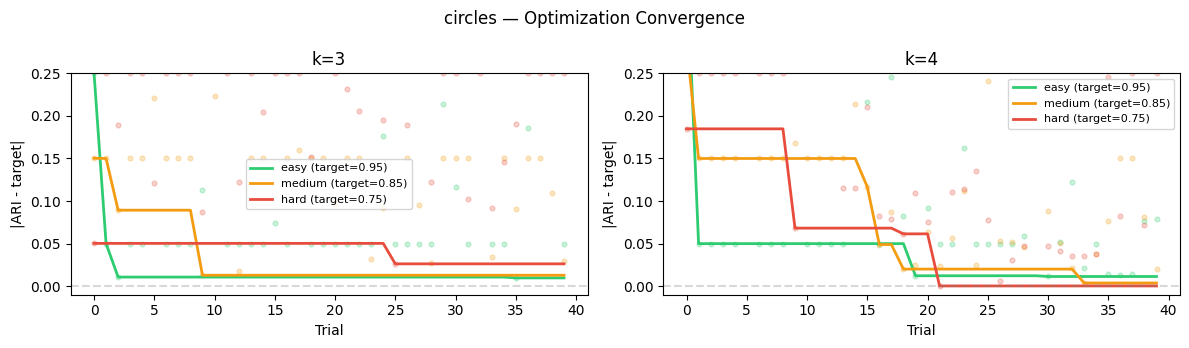

[7/18] moons k=3 easy:   0%|          | 0/40 [00:00<?, ?it/s]

[8/18] moons k=3 medium:   0%|          | 0/40 [00:00<?, ?it/s]

[9/18] moons k=3 hard:   0%|          | 0/40 [00:00<?, ?it/s]

[10/18] moons k=4 easy:   0%|          | 0/40 [00:00<?, ?it/s]

[11/18] moons k=4 medium:   0%|          | 0/40 [00:00<?, ?it/s]

[12/18] moons k=4 hard:   0%|          | 0/40 [00:00<?, ?it/s]

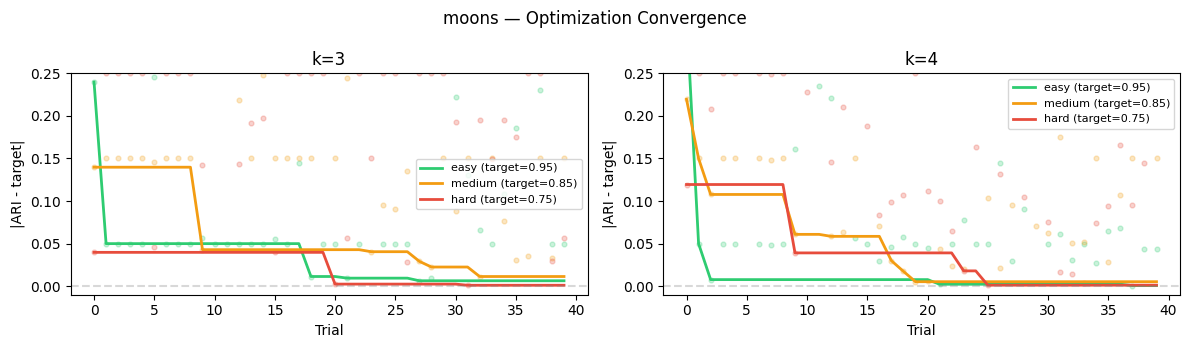

[13/18] swiss_roll k=3 easy:   0%|          | 0/40 [00:00<?, ?it/s]

[14/18] swiss_roll k=3 medium:   0%|          | 0/40 [00:00<?, ?it/s]

[15/18] swiss_roll k=3 hard:   0%|          | 0/40 [00:00<?, ?it/s]

[16/18] swiss_roll k=4 easy:   0%|          | 0/40 [00:00<?, ?it/s]

[17/18] swiss_roll k=4 medium:   0%|          | 0/40 [00:00<?, ?it/s]

[18/18] swiss_roll k=4 hard:   0%|          | 0/40 [00:00<?, ?it/s]

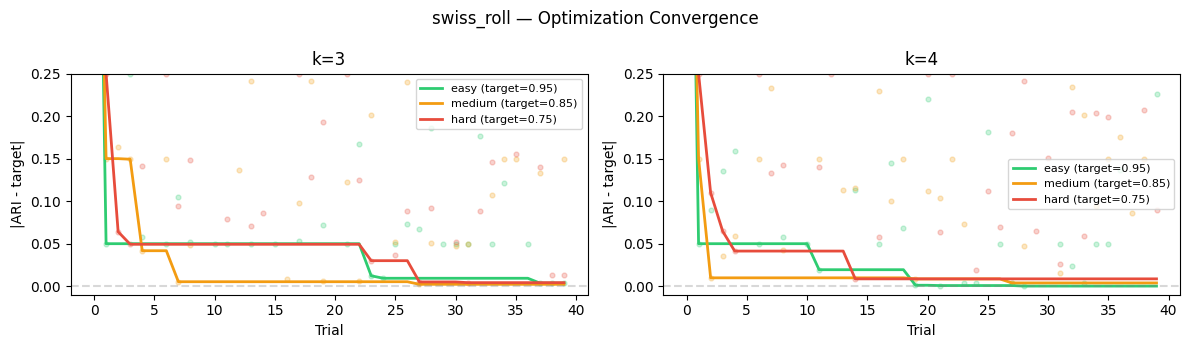


All 18 difficulty studies completed in 0.9 minutes


In [29]:
DIFF_COLORS = {"easy": "#2ecc71", "medium": "#f39c12", "hard": "#e74c3c"}

difficulty_results = {}  # (regime, k, diff) -> {params + stats}
difficulty_studies = {}  # (regime, k, diff) -> optuna.Study

total = len(REGIMES) * len(TRUE_KS) * len(DIFFICULTY_TARGETS)
study_num = 0
t0_global = time.perf_counter()

for regime_name, regime_settings in REGIMES.items():
    regime_studies = {}

    for true_k in TRUE_KS:
        for diff_name, target_ari in DIFFICULTY_TARGETS.items():
            study_num += 1
            key = (regime_name, true_k, diff_name)
            label = f"[{study_num}/{total}] {regime_name} k={true_k} {diff_name}"

            pbar = tqdm(total=N_TRIALS, desc=label, leave=True)

            best_gap = float("inf")

            def _callback(study, trial, _pbar=pbar, _target=target_ari, _bg=[best_gap]):
                _pbar.update(1)
                if trial.value < _bg[0]:
                    _bg[0] = trial.value
                    bp = study.best_trial.params
                    ba = study.best_trial.user_attrs.get("mean_ari", float("nan"))
                    _pbar.set_postfix_str(
                        f"ARI={ba:.3f} (target={_target:.2f}, gap={_bg[0]:.4f}) | "
                        f"sh={bp['scale_high']:.2f} sl={bp['scale_low']:.2f} "
                        f"corr={bp['corr_strength']:.2f} a={bp['dirichlet_alpha']:.2f} "
                        f"ep={bp['embed_param']:.1f}"
                    )

            study = optuna.create_study(
                direction="minimize",
                sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED),
                study_name=f"{regime_name}_k{true_k}_{diff_name}",
            )
            study.optimize(
                make_difficulty_objective(regime_settings, true_k, target_ari),
                n_trials=N_TRIALS,
                callbacks=[_callback],
            )
            pbar.close()

            bp = study.best_trial.params
            difficulty_results[key] = {
                "scale_high": round(bp["scale_high"], 2),
                "scale_low": round(bp["scale_low"], 2),
                "corr_strength": round(bp["corr_strength"], 2),
                "dirichlet_alpha": round(bp["dirichlet_alpha"], 2),
                "embed_param": round(bp["embed_param"], 1),
                "search_ari": round(study.best_trial.user_attrs["mean_ari"], 3),
                "search_std": round(study.best_trial.user_attrs["std_ari"], 3),
            }
            difficulty_studies[key] = study
            regime_studies[(true_k, diff_name)] = study

    # ── Inline convergence plot after each regime ──
    fig, axes = plt.subplots(1, len(TRUE_KS), figsize=(12, 3.5), squeeze=False)
    fig.suptitle(f"{regime_name} — Optimization Convergence", fontsize=12)
    for col, true_k in enumerate(TRUE_KS):
        ax = axes[0, col]
        ax.set_title(f"k={true_k}")
        ax.set_xlabel("Trial")
        ax.set_ylabel("|ARI - target|")
        for diff_name in DIFFICULTY_TARGETS:
            s = regime_studies[(true_k, diff_name)]
            vals = [t.value for t in s.trials]
            running = np.minimum.accumulate(vals)
            ax.scatter(
                range(len(vals)), vals, alpha=0.25, s=12, color=DIFF_COLORS[diff_name]
            )
            ax.plot(
                running,
                color=DIFF_COLORS[diff_name],
                lw=2,
                label=f"{diff_name} (target={DIFFICULTY_TARGETS[diff_name]:.2f})",
            )
        ax.axhline(0, color="gray", ls="--", alpha=0.3)
        ax.set_ylim(-0.01, 0.25)
        ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

elapsed = time.perf_counter() - t0_global
print(f"\nAll {total} difficulty studies completed in {elapsed / 60:.1f} minutes")

## A4) Validate

In [30]:
print(f"Validating all {total} settings with {N_SEEDS_VALIDATE} seeds each...\n")

difficulty_validated = {}
rows = []

for (regime_name, true_k, diff_name), r in difficulty_results.items():
    mean_ari, std_ari = evaluate_difficulty_params(
        REGIMES[regime_name],
        true_k,
        r["scale_high"],
        r["scale_low"],
        r["corr_strength"],
        r["dirichlet_alpha"],
        r["embed_param"],
        n_seeds=N_SEEDS_VALIDATE,
    )
    target = DIFFICULTY_TARGETS[diff_name]
    in_band = target - 0.10 <= mean_ari <= target + 0.10
    status = "OK" if in_band else "MISS"

    difficulty_validated[(regime_name, true_k, diff_name)] = {
        **r,
        "val_mean_ari": round(mean_ari, 3),
        "val_std_ari": round(std_ari, 3),
        "status": status,
    }
    rows.append(
        {
            "regime": regime_name,
            "k": true_k,
            "difficulty": diff_name,
            "target": target,
            "ARI": round(mean_ari, 3),
            "std": round(std_ari, 3),
            "status": status,
        }
    )
    print(
        f"  {regime_name:>12} k={true_k} {diff_name:>6}: "
        f"ARI={mean_ari:.3f} +/- {std_ari:.3f} (target={target:.2f}) [{status}]"
    )

n_ok = sum(1 for r in rows if r["status"] == "OK")
print(f"\n{n_ok}/{len(rows)} settings within target bands.")

Validating all 18 settings with 20 seeds each...

       circles k=3   easy: ARI=0.847 +/- 0.266 (target=0.95) [MISS]
       circles k=3 medium: ARI=0.804 +/- 0.267 (target=0.85) [OK]
       circles k=3   hard: ARI=0.774 +/- 0.279 (target=0.75) [OK]
       circles k=4   easy: ARI=0.858 +/- 0.229 (target=0.95) [OK]
       circles k=4 medium: ARI=0.828 +/- 0.227 (target=0.85) [OK]
       circles k=4   hard: ARI=0.592 +/- 0.266 (target=0.75) [MISS]
         moons k=3   easy: ARI=0.887 +/- 0.227 (target=0.95) [OK]
         moons k=3 medium: ARI=0.852 +/- 0.257 (target=0.85) [OK]
         moons k=3   hard: ARI=0.747 +/- 0.257 (target=0.75) [OK]
         moons k=4   easy: ARI=0.970 +/- 0.103 (target=0.95) [OK]
         moons k=4 medium: ARI=0.776 +/- 0.249 (target=0.85) [OK]
         moons k=4   hard: ARI=0.621 +/- 0.265 (target=0.75) [MISS]
    swiss_roll k=3   easy: ARI=0.943 +/- 0.171 (target=0.95) [OK]
    swiss_roll k=3 medium: ARI=0.848 +/- 0.233 (target=0.85) [OK]
    swiss_roll k=3  

### Validation Summary Plot

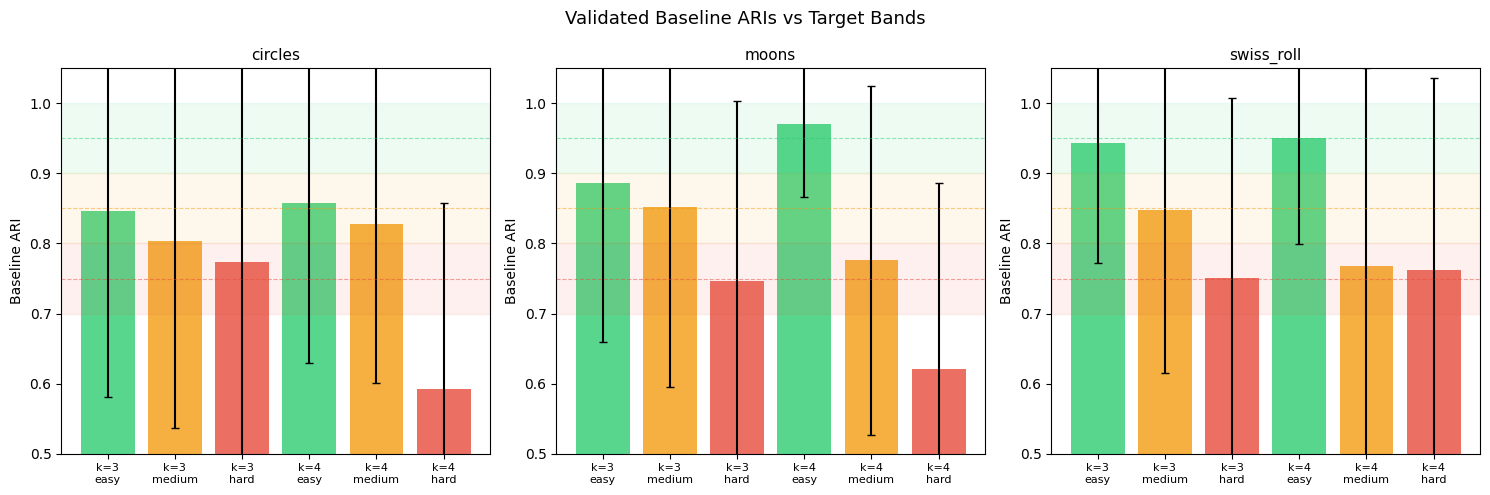

In [31]:
regimes = list(REGIMES.keys())
fig, axes = plt.subplots(1, len(regimes), figsize=(5 * len(regimes), 5), squeeze=False)
fig.suptitle("Validated Baseline ARIs vs Target Bands", fontsize=13)

for col, regime_name in enumerate(regimes):
    ax = axes[0, col]
    ax.set_title(regime_name, fontsize=11)

    x_labels, ari_vals, ari_stds, bar_colors = [], [], [], []
    for true_k in TRUE_KS:
        for diff_name in DIFFICULTY_TARGETS:
            v = difficulty_validated[(regime_name, true_k, diff_name)]
            x_labels.append(f"k={true_k}\n{diff_name}")
            ari_vals.append(v["val_mean_ari"])
            ari_stds.append(v["val_std_ari"])
            bar_colors.append(DIFF_COLORS[diff_name])

    x = np.arange(len(x_labels))
    ax.bar(x, ari_vals, yerr=ari_stds, color=bar_colors, alpha=0.8, capsize=3)
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, fontsize=8)
    ax.set_ylabel("Baseline ARI")
    ax.set_ylim(0.5, 1.05)

    # target bands
    ax.axhspan(0.9, 1.0, alpha=0.08, color=DIFF_COLORS["easy"])
    ax.axhspan(0.8, 0.9, alpha=0.08, color=DIFF_COLORS["medium"])
    ax.axhspan(0.7, 0.8, alpha=0.08, color=DIFF_COLORS["hard"])
    for ari, c in [(0.95, "easy"), (0.85, "medium"), (0.75, "hard")]:
        ax.axhline(ari, color=DIFF_COLORS[c], ls="--", alpha=0.5, lw=0.8)

plt.tight_layout()
plt.show()

## A5) Re-run Missed Settings (if any)

Re-runs missed settings with 80 trials and 15 seeds/trial. Skip if all OK.

In [32]:
misses = [(k, v) for k, v in difficulty_validated.items() if v["status"] == "MISS"]

if not misses:
    print("All settings OK — nothing to re-run!")
else:
    print(
        f"Re-running {len(misses)} missed settings with 80 trials, 15 seeds/trial...\n"
    )

    for (regime_name, true_k, diff_name), old in misses:
        target_ari = DIFFICULTY_TARGETS[diff_name]
        label = f"FIX: {regime_name} k={true_k} {diff_name}"
        pbar = tqdm(total=80, desc=label, leave=True)

        best_gap = [float("inf")]

        def _cb(study, trial, _p=pbar, _t=target_ari, _bg=best_gap):
            _p.update(1)
            if trial.value < _bg[0]:
                _bg[0] = trial.value
                ba = study.best_trial.user_attrs.get("mean_ari", float("nan"))
                _p.set_postfix_str(f"ARI={ba:.3f} gap={_bg[0]:.4f}")

        def _fix_objective(
            trial,
            _regime=regime_settings,
            _k=true_k,
            _target=target_ari,
            _regime_name=regime_name,
        ):
            sh = trial.suggest_float("scale_high", 0.5, 8.0)
            sl = trial.suggest_float("scale_low", 0.3, sh)
            cs = trial.suggest_float("corr_strength", 0.0, 0.8)
            da = trial.suggest_float("dirichlet_alpha", 0.05, 1.0)
            ep = trial.suggest_float("embed_param", 2.0, 15.0)
            mean_ari, std_ari = evaluate_difficulty_params(
                REGIMES[_regime_name],
                _k,
                sh,
                sl,
                cs,
                da,
                ep,
                n_seeds=15,
            )
            trial.set_user_attr("mean_ari", mean_ari)
            trial.set_user_attr("std_ari", std_ari)
            return abs(mean_ari - _target)

        study = optuna.create_study(
            direction="minimize",
            sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED),
        )
        study.optimize(_fix_objective, n_trials=80, callbacks=[_cb])
        pbar.close()

        bp = study.best_trial.params
        mean_ari, std_ari = evaluate_difficulty_params(
            REGIMES[regime_name],
            true_k,
            bp["scale_high"],
            bp["scale_low"],
            bp["corr_strength"],
            bp["dirichlet_alpha"],
            bp["embed_param"],
            n_seeds=30,
        )
        status = "OK" if abs(mean_ari - target_ari) <= 0.10 else "MISS"
        print(f"  -> validated ARI={mean_ari:.3f} +/- {std_ari:.3f} [{status}]")

        difficulty_validated[(regime_name, true_k, diff_name)] = {
            "scale_high": round(bp["scale_high"], 2),
            "scale_low": round(bp["scale_low"], 2),
            "corr_strength": round(bp["corr_strength"], 2),
            "dirichlet_alpha": round(bp["dirichlet_alpha"], 2),
            "embed_param": round(bp["embed_param"], 1),
            "val_mean_ari": round(mean_ari, 3),
            "val_std_ari": round(std_ari, 3),
            "status": status,
        }
        difficulty_studies[(regime_name, true_k, diff_name)] = study

    still_missed = [k for k, v in difficulty_validated.items() if v["status"] == "MISS"]
    if still_missed:
        print(f"\nWarning: {len(still_missed)} settings still outside target bands.")
    else:
        print(f"\nAll settings now within target bands!")

Re-running 3 missed settings with 80 trials, 15 seeds/trial...



FIX: circles k=3 easy:   0%|          | 0/80 [00:00<?, ?it/s]

  -> validated ARI=0.918 +/- 0.210 [OK]


FIX: circles k=4 hard:   0%|          | 0/80 [00:00<?, ?it/s]

  -> validated ARI=0.724 +/- 0.259 [OK]


FIX: moons k=4 hard:   0%|          | 0/80 [00:00<?, ?it/s]

  -> validated ARI=0.821 +/- 0.225 [OK]

All settings now within target bands!


## A6) Final Difficulty Settings

In [33]:
def _fmt_difficulty_settings(regime_name):
    """Format one regime's settings as ready-to-paste Python code."""
    var_map = {
        "circles": "settings_by_k_circles",
        "moons": "settings_by_k_moons",
        "swiss_roll": "settings_by_k_swiss_rolls",
    }
    var = var_map[regime_name]
    lines = [f"{var} = {{"]
    for true_k in TRUE_KS:
        lines.append(f"    {true_k}: {{")
        for diff_name in DIFFICULTY_TARGETS:
            v = difficulty_validated[(regime_name, true_k, diff_name)]
            scale_list = [v["scale_high"]] + [v["scale_low"]] * (true_k - 1)
            scale_str = "[" + ", ".join(str(s) for s in scale_list) + "]"
            lines.append(f'        "{diff_name}": {{')
            lines.append(f'            "cluster_scale": {scale_str},')
            lines.append(
                f'            "cluster_size_dirichlet_alpha": {v["dirichlet_alpha"]},'
            )
            lines.append(f'            "corr_strength": {v["corr_strength"]},')
            lines.append(f'            "embed_param": {v["embed_param"]},')
            lines.append(
                f"        }},  # ARI={v['val_mean_ari']:.3f} +/- {v['val_std_ari']:.3f}"
            )
        lines.append("    },")
    lines.append("}")

    other_map = {
        "circles": "other_settings_circles",
        "moons": "other_settings_moons",
        "swiss_roll": "other_settings_swiss_rolls",
    }
    regime_settings = REGIMES[regime_name]
    other_var = other_map[regime_name]
    lines.append(f"\n{other_var} = {{")
    for k2, v2 in regime_settings.items():
        lines.append(f'    "{k2}": {repr(v2)},')
    lines.append("}")

    return "\n".join(lines)


for rname in REGIMES:
    print(f"# ── {rname} ──")
    print(_fmt_difficulty_settings(rname))
    print()

# ── circles ──
settings_by_k_circles = {
    3: {
        "easy": {
            "cluster_scale": [2.91, 1.85, 1.85],
            "cluster_size_dirichlet_alpha": 0.12,
            "corr_strength": 0.18,
            "embed_param": 14.6,
        },  # ARI=0.918 +/- 0.210
        "medium": {
            "cluster_scale": [5.47, 1.91, 1.91],
            "cluster_size_dirichlet_alpha": 0.57,
            "corr_strength": 0.42,
            "embed_param": 4.4,
        },  # ARI=0.804 +/- 0.267
        "hard": {
            "cluster_scale": [3.84, 1.17, 1.17],
            "cluster_size_dirichlet_alpha": 0.33,
            "corr_strength": 0.6,
            "embed_param": 4.0,
        },  # ARI=0.774 +/- 0.279
    },
    4: {
        "easy": {
            "cluster_scale": [5.99, 3.9, 3.9, 3.9],
            "cluster_size_dirichlet_alpha": 0.65,
            "corr_strength": 0.59,
            "embed_param": 12.0,
        },  # ARI=0.858 +/- 0.229
        "medium": {
            "cluster_scale": [6.63,

---
# Part B: Scaling Benchmark Settings

Profile runtime, choose linear ranges, calibrate start/middle/end anchors (all targeting ARI ~ 0.85).

## B1) Runtime Profiling

Time a single CARVE fit (stability mode) at various axis values to determine feasible ranges.

In [34]:
def time_single_carve_fit(
    estimator: str,
    axis_name: str,
    axis_value: int,
    true_k: int = 3,
    sim_kwargs: dict | None = None,
):
    """Simulate data at one axis value, fit CARVE once (stability mode), return elapsed seconds."""
    sim_kwargs = sim_kwargs or {}
    kw = dict(sim_kwargs)
    kw[axis_name] = axis_value

    X, y = simulate_clusters(
        k=true_k,
        plotting=False,
        random_state=RANDOM_SEED,
        **kw,
    )

    grids = make_estimator_grids(
        estimator=estimator, candidate_clusters=CANDIDATE_CLUSTERS
    )
    carve = CARVE(estimator_param_grids=grids, n_jobs=N_JOBS, random_state=RANDOM_SEED)

    t0 = time.perf_counter()
    carve.fit(X, reference_labels=y, mode="stability")
    elapsed = time.perf_counter() - t0

    return elapsed, X.shape[0], X.shape[1]

In [35]:
# ── Define benchmarks and probe points ──

SCALING_BENCHMARKS = {
    "gaussian_p": {
        "estimator": "kmeans",
        "axis_name": "p",
        "probe_values": [10, 50, 100, 250, 500, 750, 1000],
        "sim_kwargs": {
            "n_total": 500,
            "p": 50,
            "cluster_scale": 4.0,
            "corr_type": "ar1",
            "corr_strength": 0.5,
            "cluster_size_dirichlet_alpha": 0.5,
        },
    },
    "gaussian_n": {
        "estimator": "kmeans",
        "axis_name": "n_total",
        "probe_values": [100, 250, 500, 1000, 2000, 3000],
        "sim_kwargs": {
            "n_total": 500,
            "p": 50,
            "cluster_scale": 4.0,
            "corr_type": "ar1",
            "corr_strength": 0.5,
            "cluster_size_dirichlet_alpha": 0.5,
        },
    },
    "moons_embed": {
        "estimator": "spectral",
        "axis_name": "embed_dim",
        "probe_values": [10, 50, 100, 250, 500, 750, 1000],
        "sim_kwargs": {
            "n_total": 500,
            "p": 50,
            "embed_dim": 64,
            "cluster_scale": [2.0, 1.0, 1.0],
            "corr_type": "ar1",
            "corr_strength": 0.5,
            "cluster_size_dirichlet_alpha": 0.5,
            "distribution": "moons",
            "nonlinear": True,
            "embed_param": 8.0,
        },
    },
    "moons_n": {
        "estimator": "spectral",
        "axis_name": "n_total",
        "probe_values": [100, 250, 500, 1000, 2000, 3000],
        "sim_kwargs": {
            "n_total": 500,
            "p": 50,
            "embed_dim": 64,
            "cluster_scale": [2.0, 1.0, 1.0],
            "corr_type": "ar1",
            "corr_strength": 0.5,
            "cluster_size_dirichlet_alpha": 0.5,
            "distribution": "moons",
            "nonlinear": True,
            "embed_param": 8.0,
        },
    },
}

In [36]:
# ── Run profiling (parallelized: probe values within each benchmark) ──


def _profile_one(bench_name, bench, val):
    """Profile a single (benchmark, probe_value) pair."""
    try:
        elapsed, n, p = time_single_carve_fit(
            estimator=bench["estimator"],
            axis_name=bench["axis_name"],
            axis_value=val,
            true_k=3,
            sim_kwargs=bench["sim_kwargs"],
        )
        return {"axis_value": val, "seconds": elapsed, "n": n, "p": p}
    except Exception as e:
        return {
            "axis_value": val,
            "seconds": np.nan,
            "n": np.nan,
            "p": np.nan,
            "error": str(e),
        }


timing_results = {}

for bench_name, bench in SCALING_BENCHMARKS.items():
    print(f"\nProfiling: {bench_name} (axis={bench['axis_name']})")
    results = Parallel(n_jobs=N_JOBS)(
        delayed(_profile_one)(bench_name, bench, val) for val in bench["probe_values"]
    )
    timing_results[bench_name] = results

    for d in results:
        if np.isfinite(d["seconds"]):
            print(
                f"  {bench['axis_name']}={d['axis_value']:>6}: {d['seconds']:6.1f}s  (data: {int(d['n'])}x{int(d['p'])})"
            )
        else:
            print(
                f"  {bench['axis_name']}={d['axis_value']:>6}: FAILED ({d.get('error', '?')})"
            )


Profiling: gaussian_p (axis=p)
[CARVE] ============================================================
[CARVE] Validation Settings:
[CARVE] n_samples          : 500
[CARVE] n_features         : 10
[CARVE] n_clusters         : [2, 3, 4, 5, 6, 7]
[CARVE] n_resamples        : 100
[CARVE] subsample_ratio    : 0.8
[CARVE] n_jobs             : 10
[CARVE] total configs      : 6
[CARVE] randomize_preproc  : False
[CARVE] random_state       : 42
[CARVE] ============================================================

[CARVE] Starting validation ...

[CARVE] ============================================================
[CARVE] Validation Settings:
[CARVE] n_samples          : 500
[CARVE] n_features         : 50
[CARVE] n_clusters         : [2, 3, 4, 5, 6, 7]
[CARVE] n_resamples        : 100
[CARVE] subsample_ratio    : 0.8
[CARVE] n_jobs             : 10
[CARVE] total configs      : 6
[CARVE] randomize_preproc  : False
[CARVE] random_state       : 42
[CARVE] ===========================================

/var/folders/l_/sb8sl5s14cxc7f15c67l1lg00000gn/T/ipykernel_98950/1147491677.py:21: RuntimeWarning: Non-default mode is experimental and may break downstream functionality.
/var/folders/l_/sb8sl5s14cxc7f15c67l1lg00000gn/T/ipykernel_98950/1147491677.py:21: RuntimeWarning: Non-default mode is experimental and may break downstream functionality.
/var/folders/l_/sb8sl5s14cxc7f15c67l1lg00000gn/T/ipykernel_98950/1147491677.py:21: RuntimeWarning: Non-default mode is experimental and may break downstream functionality.
/var/folders/l_/sb8sl5s14cxc7f15c67l1lg00000gn/T/ipykernel_98950/1147491677.py:21: RuntimeWarning: Non-default mode is experimental and may break downstream functionality.
/var/folders/l_/sb8sl5s14cxc7f15c67l1lg00000gn/T/ipykernel_98950/1147491677.py:21: RuntimeWarning: Non-default mode is experimental and may break downstream functionality.
/var/folders/l_/sb8sl5s14cxc7f15c67l1lg00000gn/T/ipykernel_98950/1147491677.py:21: RuntimeWarning: Non-default mode is experimental and may 

[CARVE] ============================================================
[CARVE] Validation Settings:
[CARVE] n_samples          : 500
[CARVE] n_features         : 750
[CARVE] n_clusters         : [2, 3, 4, 5, 6, 7]
[CARVE] n_resamples        : 100
[CARVE] subsample_ratio    : 0.8
[CARVE] n_jobs             : 10
[CARVE] total configs      : 6
[CARVE] randomize_preproc  : False
[CARVE] random_state       : 42
[CARVE] ============================================================

[CARVE] Starting validation ...



/var/folders/l_/sb8sl5s14cxc7f15c67l1lg00000gn/T/ipykernel_98950/1147491677.py:21: RuntimeWarning: Non-default mode is experimental and may break downstream functionality.


[CARVE] ============================================================
[CARVE] Validation Settings:
[CARVE] n_samples          : 500
[CARVE] n_features         : 1000
[CARVE] n_clusters         : [2, 3, 4, 5, 6, 7]
[CARVE] n_resamples        : 100
[CARVE] subsample_ratio    : 0.8
[CARVE] n_jobs             : 10
[CARVE] total configs      : 6
[CARVE] randomize_preproc  : False
[CARVE] random_state       : 42
[CARVE] ============================================================

[CARVE] Starting validation ...

[CARVE] [1/6] est=KMeans n_clusters=2 | ARI_stab=0.935±0.005  ARI_gen=nan±nan  
[CARVE] [1/6] est=KMeans n_clusters=2 | ARI_stab=0.717±0.026  ARI_gen=nan±nan  
[CARVE] [1/6] est=KMeans n_clusters=2 | ARI_stab=0.971±0.002  ARI_gen=nan±nan  
[CARVE] [1/6] est=KMeans n_clusters=2 | ARI_stab=1.000±0.000  ARI_gen=nan±nan  
[CARVE] [1/6] est=KMeans n_clusters=2 | ARI_stab=1.000±0.000  ARI_gen=nan±nan  
[CARVE] [1/6] est=KMeans n_clusters=2 | ARI_stab=1.000±0.000  ARI_gen=nan±nan  
[CARVE] 

...

[CARVE] [1/6] est=KMeans n_clusters=2 | ARI_stab=0.963±0.008  ARI_gen=nan±nan  
[CARVE] [1/6] est=KMeans n_clusters=2 | ARI_stab=0.944±0.005  ARI_gen=nan±nan  
[CARVE] [1/6] est=KMeans n_clusters=2 | ARI_stab=0.935±0.005  ARI_gen=nan±nan  
[CARVE] [2/6] est=KMeans n_clusters=3 | ARI_stab=0.576±0.014  ARI_gen=nan±nan  
[CARVE] [2/6] est=KMeans n_clusters=3 | ARI_stab=0.754±0.014  ARI_gen=nan±nan  
[CARVE] [1/6] est=KMeans n_clusters=2 | ARI_stab=0.937±0.004  ARI_gen=nan±nan  
[CARVE] [3/6] est=KMeans n_clusters=4 | ARI_stab=0.435±0.014  ARI_gen=nan±nan  
[CARVE] [2/6] est=KMeans n_clusters=3 | ARI_stab=0.893±0.008  ARI_gen=nan±nan  
[CARVE] [4/6] est=KMeans n_clusters=5 | ARI_stab=0.361±0.011  ARI_gen=nan±nan  
[CARVE] [3/6] est=KMeans n_clusters=4 | ARI_stab=0.655±0.011  ARI_gen=nan±nan  
[CARVE] [1/6] est=KMeans n_clusters=2 | ARI_stab=0.953±0.003  ARI_gen=nan±nan  
[CARVE] [5/6] est=KMeans n_clusters=6 | ARI_stab=0.346±0.009  ARI_gen=nan±nan  
[CARVE] [3/6] est=KMeans n_clusters=4 | 

/var/folders/l_/sb8sl5s14cxc7f15c67l1lg00000gn/T/ipykernel_98950/1147491677.py:21: RuntimeWarning: Non-default mode is experimental and may break downstream functionality.
/var/folders/l_/sb8sl5s14cxc7f15c67l1lg00000gn/T/ipykernel_98950/1147491677.py:21: RuntimeWarning: Non-default mode is experimental and may break downstream functionality.
/var/folders/l_/sb8sl5s14cxc7f15c67l1lg00000gn/T/ipykernel_98950/1147491677.py:21: RuntimeWarning: Non-default mode is experimental and may break downstream functionality.
/var/folders/l_/sb8sl5s14cxc7f15c67l1lg00000gn/T/ipykernel_98950/1147491677.py:21: RuntimeWarning: Non-default mode is experimental and may break downstream functionality.
/var/folders/l_/sb8sl5s14cxc7f15c67l1lg00000gn/T/ipykernel_98950/1147491677.py:21: RuntimeWarning: Non-default mode is experimental and may break downstream functionality.
/var/folders/l_/sb8sl5s14cxc7f15c67l1lg00000gn/T/ipykernel_98950/1147491677.py:21: RuntimeWarning: Non-default mode is experimental and may 

[CARVE] [1/6] est=SpectralClusteringCARVE n_clusters=2 | ARI_stab=1.000±0.000  ARI_gen=nan±nan  
[CARVE] [1/6] est=SpectralClusteringCARVE n_clusters=2 | ARI_stab=1.000±0.000  ARI_gen=nan±nan  
[CARVE] [1/6] est=SpectralClusteringCARVE n_clusters=2 | ARI_stab=1.000±0.000  ARI_gen=nan±nan  
[CARVE] [1/6] est=SpectralClusteringCARVE n_clusters=2 | ARI_stab=1.000±0.000  ARI_gen=nan±nan  
[CARVE] [1/6] est=SpectralClusteringCARVE n_clusters=2 | ARI_stab=1.000±0.000  ARI_gen=nan±nan  
[CARVE] [1/6] est=SpectralClusteringCARVE n_clusters=2 | ARI_stab=1.000±0.000  ARI_gen=nan±nan  
[CARVE] [1/6] est=SpectralClusteringCARVE n_clusters=2 | ARI_stab=1.000±0.000  ARI_gen=nan±nan  
[CARVE] [2/6] est=SpectralClusteringCARVE n_clusters=3 | ARI_stab=1.000±0.000  ARI_gen=nan±nan  
[CARVE] [2/6] est=SpectralClusteringCARVE n_clusters=3 | ARI_stab=0.933±0.012  ARI_gen=nan±nan  
[CARVE] [2/6] est=SpectralClusteringCARVE n_clusters=3 | ARI_stab=1.000±0.000  ARI_gen=nan±nan  
[CARVE] [2/6] est=SpectralClus

/var/folders/l_/sb8sl5s14cxc7f15c67l1lg00000gn/T/ipykernel_98950/1147491677.py:21: RuntimeWarning: Non-default mode is experimental and may break downstream functionality.
/var/folders/l_/sb8sl5s14cxc7f15c67l1lg00000gn/T/ipykernel_98950/1147491677.py:21: RuntimeWarning: Non-default mode is experimental and may break downstream functionality.
/var/folders/l_/sb8sl5s14cxc7f15c67l1lg00000gn/T/ipykernel_98950/1147491677.py:21: RuntimeWarning: Non-default mode is experimental and may break downstream functionality.
/var/folders/l_/sb8sl5s14cxc7f15c67l1lg00000gn/T/ipykernel_98950/1147491677.py:21: RuntimeWarning: Non-default mode is experimental and may break downstream functionality.
/var/folders/l_/sb8sl5s14cxc7f15c67l1lg00000gn/T/ipykernel_98950/1147491677.py:21: RuntimeWarning: Non-default mode is experimental and may break downstream functionality.
/var/folders/l_/sb8sl5s14cxc7f15c67l1lg00000gn/T/ipykernel_98950/1147491677.py:21: RuntimeWarning: Non-default mode is experimental and may 

[CARVE] [1/6] est=SpectralClusteringCARVE n_clusters=2 | ARI_stab=0.923±0.008  ARI_gen=nan±nan  
[CARVE] [2/6] est=SpectralClusteringCARVE n_clusters=3 | ARI_stab=0.951±0.009  ARI_gen=nan±nan  
[CARVE] [1/6] est=SpectralClusteringCARVE n_clusters=2 | ARI_stab=1.000±0.000  ARI_gen=nan±nan  
[CARVE] [3/6] est=SpectralClusteringCARVE n_clusters=4 | ARI_stab=0.654±0.018  ARI_gen=nan±nan  
[CARVE] [4/6] est=SpectralClusteringCARVE n_clusters=5 | ARI_stab=0.664±0.016  ARI_gen=nan±nan  
[CARVE] [2/6] est=SpectralClusteringCARVE n_clusters=3 | ARI_stab=0.983±0.006  ARI_gen=nan±nan  
[CARVE] [5/6] est=SpectralClusteringCARVE n_clusters=6 | ARI_stab=0.688±0.013  ARI_gen=nan±nan  
[CARVE] [6/6] est=SpectralClusteringCARVE n_clusters=7 | ARI_stab=0.707±0.012  ARI_gen=nan±nan  

[CARVE] finished. evaluated 6 estimator configurations.
[CARVE] [3/6] est=SpectralClusteringCARVE n_clusters=4 | ARI_stab=0.764±0.020  ARI_gen=nan±nan  
[CARVE] [1/6] est=SpectralClusteringCARVE n_clusters=2 | ARI_stab=1.00

### Runtime Curves + Budget Lines

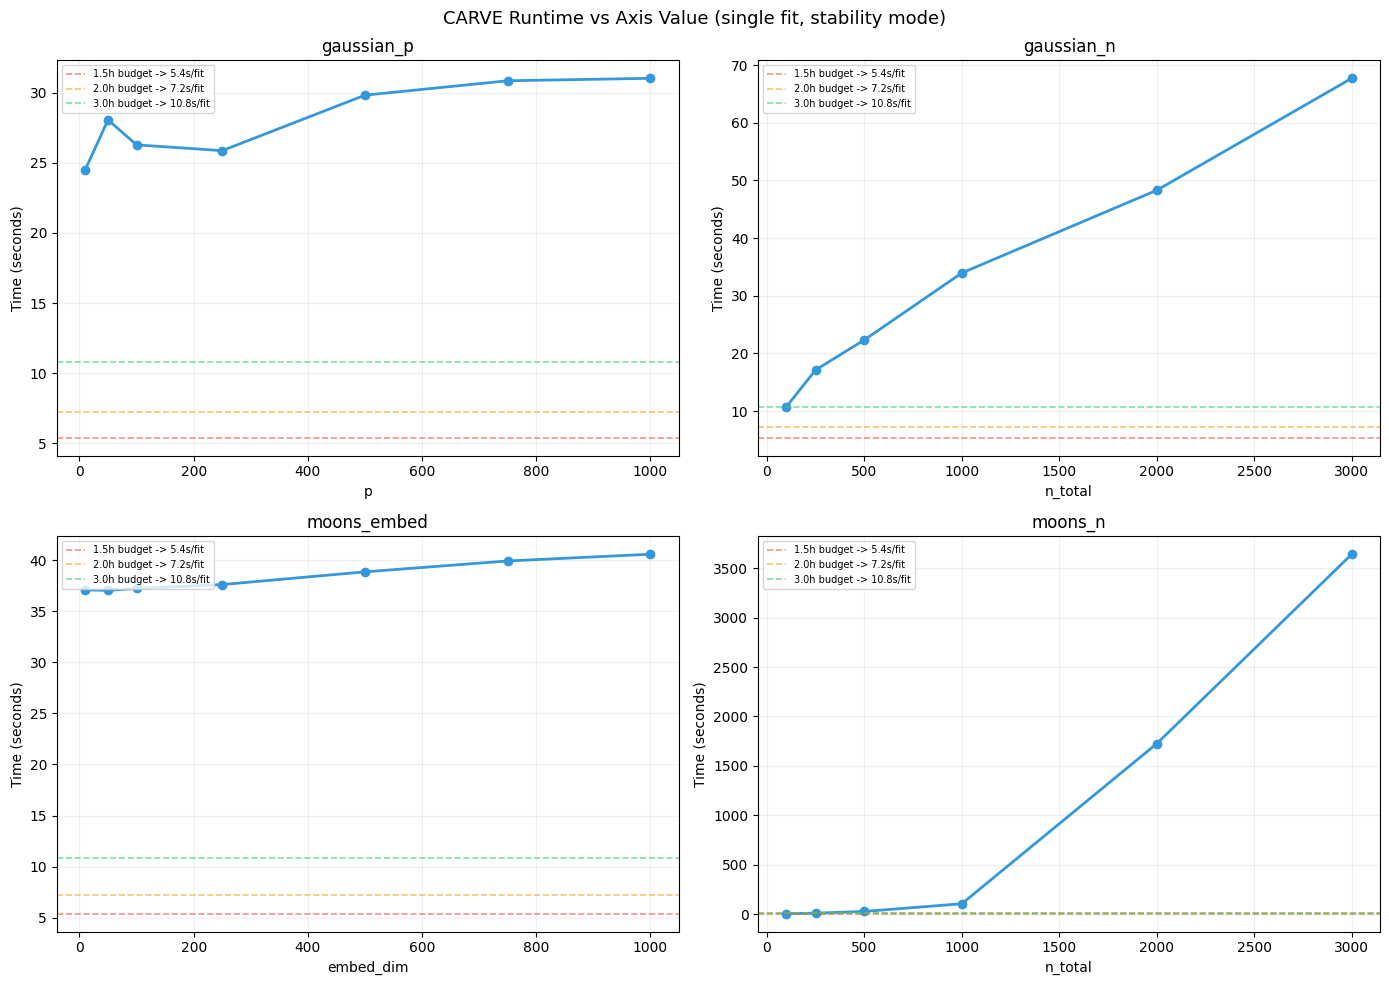

In [37]:
# Each benchmark: 10 granularity * 20 seeds * 2 k * 2 fits = 800 CARVE fits
# plus external metrics overhead => ~OVERHEAD_FACTOR
GRANULARITY = 10
N_SEEDS_BENCH = 20
ITERS_PER_BENCHMARK = GRANULARITY * N_SEEDS_BENCH * len(TRUE_KS)  # 400
OVERHEAD_FACTOR = 2.5  # 2 CARVE fits + external metrics

BUDGET_HOURS = [1.5, 2.0, 3.0]
BUDGET_COLORS = ["#e74c3c", "#f39c12", "#2ecc71"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("CARVE Runtime vs Axis Value (single fit, stability mode)", fontsize=13)

for idx, (bench_name, bench) in enumerate(SCALING_BENCHMARKS.items()):
    ax = axes.flat[idx]
    data = timing_results[bench_name]
    xs = [d["axis_value"] for d in data if np.isfinite(d["seconds"])]
    ys = [d["seconds"] for d in data if np.isfinite(d["seconds"])]

    ax.plot(xs, ys, "o-", color="#3498db", linewidth=2, markersize=6)
    ax.set_xlabel(bench["axis_name"])
    ax.set_ylabel("Time (seconds)")
    ax.set_title(f"{bench_name}")

    for hours, color in zip(BUDGET_HOURS, BUDGET_COLORS):
        max_seconds = (hours * 3600) / (ITERS_PER_BENCHMARK * OVERHEAD_FACTOR)
        ax.axhline(
            max_seconds,
            color=color,
            ls="--",
            alpha=0.6,
            lw=1.2,
            label=f"{hours}h budget -> {max_seconds:.1f}s/fit",
        )

    ax.legend(fontsize=7, loc="upper left")
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

### Estimated Total Runtimes

In [38]:
print("Estimated total benchmark time (hours) if max axis value is:")
print("(assumes mean fit time ~ 0.6 * time_at_max due to linear range)\n")

for bench_name, bench in SCALING_BENCHMARKS.items():
    data = timing_results[bench_name]
    print(f"  {bench_name} (axis={bench['axis_name']}):")
    for d in data:
        if not np.isfinite(d["seconds"]):
            continue
        avg_time = 0.6 * d["seconds"]
        total_hours = (ITERS_PER_BENCHMARK * OVERHEAD_FACTOR * avg_time) / 3600
        flag = "" if total_hours <= 3.0 else " *** TOO SLOW"
        print(f"    max={d['axis_value']:>6} -> ~{total_hours:.1f}h{flag}")
    print()

Estimated total benchmark time (hours) if max axis value is:
(assumes mean fit time ~ 0.6 * time_at_max due to linear range)

  gaussian_p (axis=p):
    max=    10 -> ~4.1h *** TOO SLOW
    max=    50 -> ~4.7h *** TOO SLOW
    max=   100 -> ~4.4h *** TOO SLOW
    max=   250 -> ~4.3h *** TOO SLOW
    max=   500 -> ~5.0h *** TOO SLOW
    max=   750 -> ~5.1h *** TOO SLOW
    max=  1000 -> ~5.2h *** TOO SLOW

  gaussian_n (axis=n_total):
    max=   100 -> ~1.8h
    max=   250 -> ~2.9h
    max=   500 -> ~3.7h *** TOO SLOW
    max=  1000 -> ~5.7h *** TOO SLOW
    max=  2000 -> ~8.0h *** TOO SLOW
    max=  3000 -> ~11.3h *** TOO SLOW

  moons_embed (axis=embed_dim):
    max=    10 -> ~6.2h *** TOO SLOW
    max=    50 -> ~6.2h *** TOO SLOW
    max=   100 -> ~6.2h *** TOO SLOW
    max=   250 -> ~6.3h *** TOO SLOW
    max=   500 -> ~6.5h *** TOO SLOW
    max=   750 -> ~6.7h *** TOO SLOW
    max=  1000 -> ~6.8h *** TOO SLOW

  moons_n (axis=n_total):
    max=   100 -> ~0.8h
    max=   250 -> ~1.6

## B2) Choose Linear Ranges

Edit the ranges below based on the profiling results above.

In [39]:
# ── EDIT THESE based on the profiling results above ──

SCALING_RANGES = {
    "gaussian_p": {"min": 10, "max": 500},  # p (features)
    "gaussian_n": {"min": 100, "max": 3000},  # n_total (samples)
    "moons_embed": {"min": 10, "max": 500},  # embed_dim
    "moons_n": {"min": 100, "max": 2000},  # n_total (samples)
}

for name, r in SCALING_RANGES.items():
    bench = SCALING_BENCHMARKS[name]
    x_values = np.linspace(r["min"], r["max"], GRANULARITY).astype(int).tolist()
    print(f"{name:>15} ({bench['axis_name']:>9}): {x_values}")

     gaussian_p (        p): [10, 64, 118, 173, 227, 282, 336, 391, 445, 500]
     gaussian_n (  n_total): [100, 422, 744, 1066, 1388, 1711, 2033, 2355, 2677, 3000]
    moons_embed (embed_dim): [10, 64, 118, 173, 227, 282, 336, 391, 445, 500]
        moons_n (  n_total): [100, 311, 522, 733, 944, 1155, 1366, 1577, 1788, 2000]


## B3) Calibrate Start / Middle / End Settings

For each benchmark and k, Optuna finds settings producing baseline ARI ~ 0.85
at the three anchor points (min, mid, max of the chosen range).

In [40]:
N_TRIALS_SCALING = 40
TARGET_ARI = 0.85

BENCH_CONFIGS = {
    "gaussian_p": {
        "estimator": "kmeans",
        "axis_name": "p",
        "base_sim_kwargs": {
            "n_total": 500,
            "corr_type": "ar1",
            "corr_strength": 0.5,
            "cluster_size_dirichlet_alpha": 0.5,
        },
        "search_params": ["cluster_scale_uniform"],
    },
    "gaussian_n": {
        "estimator": "kmeans",
        "axis_name": "n_total",
        "base_sim_kwargs": {
            "p": 50,
            "corr_type": "ar1",
            "corr_strength": 0.5,
            "cluster_size_dirichlet_alpha": 0.5,
        },
        "search_params": ["cluster_scale_uniform"],
    },
    "moons_embed": {
        "estimator": "spectral",
        "axis_name": "embed_dim",
        "base_sim_kwargs": {
            "n_total": 500,
            "p": 50,
            "corr_type": "ar1",
            "corr_strength": 0.5,
            "cluster_size_dirichlet_alpha": 0.5,
            "distribution": "moons",
            "nonlinear": True,
        },
        "search_params": ["cluster_scale_varied", "embed_param"],
    },
    "moons_n": {
        "estimator": "spectral",
        "axis_name": "n_total",
        "base_sim_kwargs": {
            "p": 50,
            "embed_dim": 64,
            "corr_type": "ar1",
            "corr_strength": 0.5,
            "cluster_size_dirichlet_alpha": 0.5,
            "distribution": "moons",
            "nonlinear": True,
        },
        "search_params": ["cluster_scale_varied", "embed_param"],
    },
}

In [41]:
def _eval_scaling_seed(
    seed,
    true_k,
    estimator,
    axis_name,
    axis_value,
    sim_kwargs,
    cluster_scale,
    embed_param=None,
):
    """Simulate + cluster at one axis value, return ARI."""
    benchmark_seed = seed + ((true_k - min(TRUE_KS)) * 100) + RANDOM_SEED

    kw = dict(sim_kwargs)
    kw["k"] = true_k
    kw["cluster_scale"] = cluster_scale
    if embed_param is not None:
        kw["embed_param"] = embed_param
    kw[axis_name] = axis_value

    X, y = simulate_clusters(plotting=False, random_state=benchmark_seed, **kw)

    grids = make_estimator_grids(
        estimator=estimator, candidate_clusters=CANDIDATE_CLUSTERS
    )
    est_cls, est_params = grids[0]
    est = _build_estimator(est_cls, true_k, est_params, benchmark_seed)
    labels = est.fit_predict(X)
    return adjusted_rand_score(y, labels)


def eval_scaling_params(
    estimator,
    axis_name,
    axis_value,
    true_k,
    sim_kwargs,
    cluster_scale,
    embed_param=None,
    n_seeds=N_SEEDS_SEARCH,
):
    """Return (mean_ari, std_ari) parallelized over seeds."""
    aris = Parallel(n_jobs=N_JOBS)(
        delayed(_eval_scaling_seed)(
            seed,
            true_k,
            estimator,
            axis_name,
            axis_value,
            sim_kwargs,
            cluster_scale,
            embed_param,
        )
        for seed in range(n_seeds)
    )
    return float(np.mean(aris)), float(np.std(aris))


def make_scaling_objective(bench_config, axis_value, true_k):
    """Optuna objective for one anchor point."""
    estimator = bench_config["estimator"]
    axis_name = bench_config["axis_name"]
    sim_kwargs = bench_config["base_sim_kwargs"]
    search_params = bench_config["search_params"]

    def objective(trial):
        if "cluster_scale_uniform" in search_params:
            cs_val = trial.suggest_float("cluster_scale", 0.5, 10.0)
            cluster_scale = [cs_val] * true_k
        else:
            sh = trial.suggest_float("scale_high", 0.5, 8.0)
            sl = trial.suggest_float("scale_low", 0.3, sh)
            cluster_scale = [sh] + [sl] * (true_k - 1)

        embed_param = None
        if "embed_param" in search_params:
            embed_param = trial.suggest_float("embed_param", 2.0, 15.0)

        mean_ari, std_ari = eval_scaling_params(
            estimator,
            axis_name,
            axis_value,
            true_k,
            sim_kwargs,
            cluster_scale,
            embed_param,
        )
        trial.set_user_attr("mean_ari", mean_ari)
        trial.set_user_attr("std_ari", std_ari)
        return abs(mean_ari - TARGET_ARI)

    return objective

[1/24] gaussian_p k=3 start (p=10):   0%|          | 0/40 [00:00<?, ?it/s]

/Users/kaiwycik/GitHub/ClusteringValidation/code/.venv/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[2/24] gaussian_p k=3 middle (p=255):   0%|          | 0/40 [00:00<?, ?it/s]

[3/24] gaussian_p k=3 end (p=500):   0%|          | 0/40 [00:00<?, ?it/s]

[4/24] gaussian_p k=4 start (p=10):   0%|          | 0/40 [00:00<?, ?it/s]

[5/24] gaussian_p k=4 middle (p=255):   0%|          | 0/40 [00:00<?, ?it/s]

[6/24] gaussian_p k=4 end (p=500):   0%|          | 0/40 [00:00<?, ?it/s]

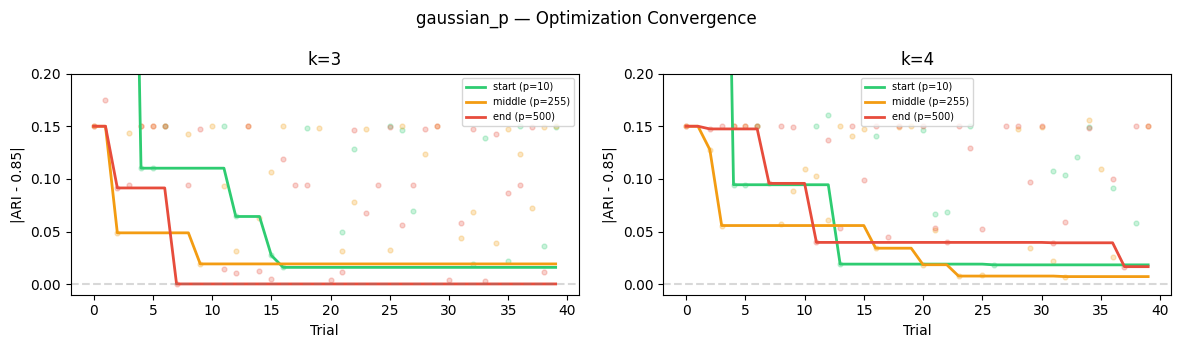

[7/24] gaussian_n k=3 start (n_total=100):   0%|          | 0/40 [00:00<?, ?it/s]

[8/24] gaussian_n k=3 middle (n_total=1550):   0%|          | 0/40 [00:00<?, ?it/s]

[9/24] gaussian_n k=3 end (n_total=3000):   0%|          | 0/40 [00:00<?, ?it/s]

[10/24] gaussian_n k=4 start (n_total=100):   0%|          | 0/40 [00:00<?, ?it/s]

[11/24] gaussian_n k=4 middle (n_total=1550):   0%|          | 0/40 [00:00<?, ?it/s]

[12/24] gaussian_n k=4 end (n_total=3000):   0%|          | 0/40 [00:00<?, ?it/s]

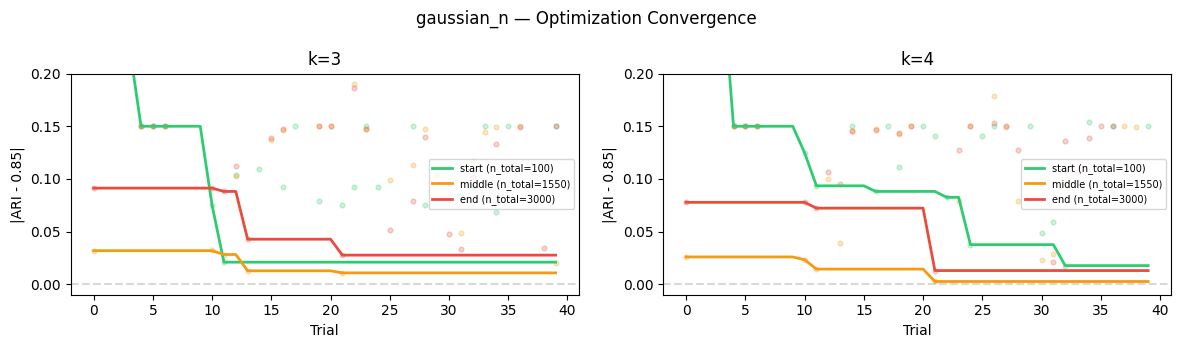

[13/24] moons_embed k=3 start (embed_dim=10):   0%|          | 0/40 [00:00<?, ?it/s]

[14/24] moons_embed k=3 middle (embed_dim=255):   0%|          | 0/40 [00:00<?, ?it/s]

[15/24] moons_embed k=3 end (embed_dim=500):   0%|          | 0/40 [00:00<?, ?it/s]

[16/24] moons_embed k=4 start (embed_dim=10):   0%|          | 0/40 [00:00<?, ?it/s]

[17/24] moons_embed k=4 middle (embed_dim=255):   0%|          | 0/40 [00:00<?, ?it/s]

[18/24] moons_embed k=4 end (embed_dim=500):   0%|          | 0/40 [00:00<?, ?it/s]

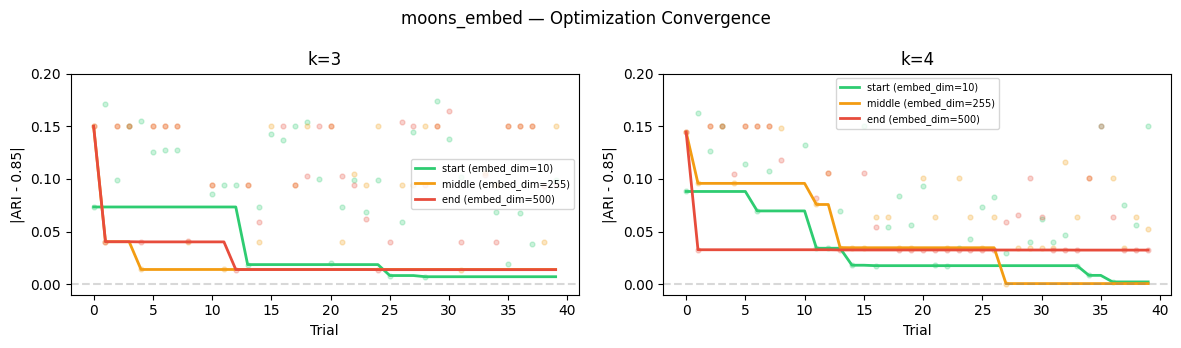

[19/24] moons_n k=3 start (n_total=100):   0%|          | 0/40 [00:00<?, ?it/s]

[20/24] moons_n k=3 middle (n_total=1050):   0%|          | 0/40 [00:00<?, ?it/s]

[21/24] moons_n k=3 end (n_total=2000):   0%|          | 0/40 [00:00<?, ?it/s]

[22/24] moons_n k=4 start (n_total=100):   0%|          | 0/40 [00:00<?, ?it/s]

[23/24] moons_n k=4 middle (n_total=1050):   0%|          | 0/40 [00:00<?, ?it/s]

[24/24] moons_n k=4 end (n_total=2000):   0%|          | 0/40 [00:00<?, ?it/s]

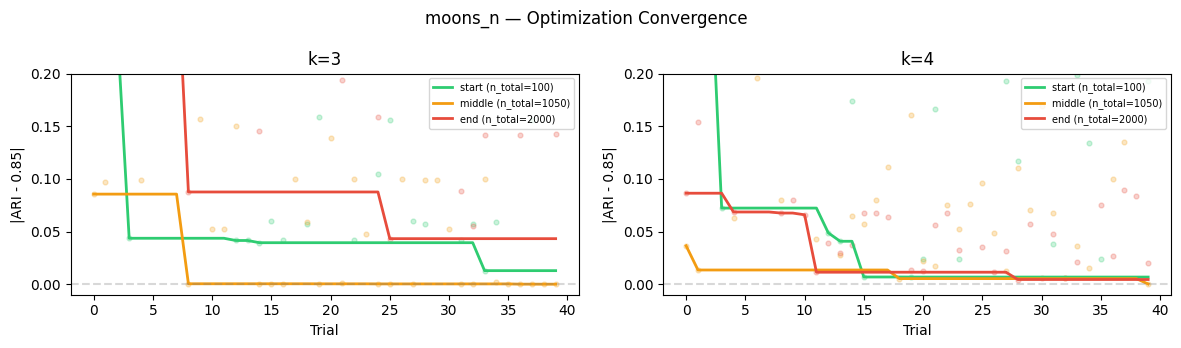


Scaling calibration completed in 21.6 minutes


In [42]:
# ── Run calibration for all anchors ──

ANCHOR_NAMES = ["start", "middle", "end"]

scaling_results = {}  # (bench_name, k, anchor) -> {params...}

total_scaling_studies = len(BENCH_CONFIGS) * len(TRUE_KS) * 3
study_num = 0
t0_cal = time.perf_counter()

for bench_name, bench_config in BENCH_CONFIGS.items():
    rng = SCALING_RANGES[bench_name]
    anchor_values = {
        "start": rng["min"],
        "middle": int((rng["min"] + rng["max"]) / 2),
        "end": rng["max"],
    }

    regime_studies = {}

    for true_k in TRUE_KS:
        for anchor_name in ANCHOR_NAMES:
            study_num += 1
            axis_val = anchor_values[anchor_name]
            label = (
                f"[{study_num}/{total_scaling_studies}] {bench_name} k={true_k} "
                f"{anchor_name} ({bench_config['axis_name']}={axis_val})"
            )

            pbar = tqdm(total=N_TRIALS_SCALING, desc=label, leave=True)

            best_gap = [float("inf")]

            def _cb(study, trial, _p=pbar, _bg=best_gap):
                _p.update(1)
                if trial.value < _bg[0]:
                    _bg[0] = trial.value
                    ba = study.best_trial.user_attrs.get("mean_ari", float("nan"))
                    _p.set_postfix_str(f"ARI={ba:.3f} gap={_bg[0]:.4f}")

            study = optuna.create_study(
                direction="minimize",
                sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED),
            )
            study.optimize(
                make_scaling_objective(bench_config, axis_val, true_k),
                n_trials=N_TRIALS_SCALING,
                callbacks=[_cb],
            )
            pbar.close()

            bp = study.best_trial.params
            result = {
                "axis_value": axis_val,
                "search_ari": round(study.best_trial.user_attrs["mean_ari"], 3),
            }
            if "cluster_scale" in bp:
                result["cluster_scale"] = [round(bp["cluster_scale"], 2)] * true_k
            else:
                result["cluster_scale"] = [round(bp["scale_high"], 2)] + [
                    round(bp["scale_low"], 2)
                ] * (true_k - 1)
            if "embed_param" in bp:
                result["embed_param"] = round(bp["embed_param"], 1)

            scaling_results[(bench_name, true_k, anchor_name)] = result
            regime_studies[(true_k, anchor_name)] = study

    # ── Convergence plot per benchmark ──
    fig, axes_cv = plt.subplots(1, len(TRUE_KS), figsize=(12, 3.5), squeeze=False)
    fig.suptitle(f"{bench_name} — Optimization Convergence", fontsize=12)
    anchor_colors = {"start": "#2ecc71", "middle": "#f39c12", "end": "#e74c3c"}
    for col, true_k in enumerate(TRUE_KS):
        ax = axes_cv[0, col]
        ax.set_title(f"k={true_k}")
        ax.set_xlabel("Trial")
        ax.set_ylabel("|ARI - 0.85|")
        for anchor_name in ANCHOR_NAMES:
            s = regime_studies[(true_k, anchor_name)]
            vals = [t.value for t in s.trials]
            running = np.minimum.accumulate(vals)
            ax.scatter(
                range(len(vals)),
                vals,
                alpha=0.25,
                s=12,
                color=anchor_colors[anchor_name],
            )
            ax.plot(
                running,
                color=anchor_colors[anchor_name],
                lw=2,
                label=f"{anchor_name} ({bench_config['axis_name']}={anchor_values[anchor_name]})",
            )
        ax.axhline(0, color="gray", ls="--", alpha=0.3)
        ax.set_ylim(-0.01, 0.20)
        ax.legend(fontsize=7)
    plt.tight_layout()
    plt.show()

elapsed_cal = time.perf_counter() - t0_cal
print(f"\nScaling calibration completed in {elapsed_cal / 60:.1f} minutes")

## B4) Validate Across Full Range

Simulate at all 10 linear points with interpolated settings, check ARI ~ 0.85.

In [43]:
def interpolate_settings(
    stage, total_stages, start_settings, middle_settings, end_settings
):
    """Interpolate between start/middle/end, matching parse_range_and_simulate logic."""
    mid_idx = int(round(total_stages // 2))

    if stage == 0:
        return start_settings
    elif stage == mid_idx:
        return middle_settings
    elif stage == total_stages - 1:
        return end_settings
    elif stage < mid_idx:
        frac = stage / mid_idx
        result = {}
        for key in start_settings:
            v_s = np.array(start_settings[key])
            v_m = np.array(middle_settings[key])
            result[key] = ((1 - frac) * v_s + frac * v_m).tolist()
        return result
    else:
        frac = (stage - mid_idx) / (total_stages - 1 - mid_idx)
        result = {}
        for key in middle_settings:
            v_m = np.array(middle_settings[key])
            v_e = np.array(end_settings[key])
            result[key] = ((1 - frac) * v_m + frac * v_e).tolist()
        return result


def build_anchor_settings(bench_name, true_k):
    """Extract start/middle/end dicts for one (bench, k)."""
    out = {}
    for anchor_name in ANCHOR_NAMES:
        r = scaling_results[(bench_name, true_k, anchor_name)]
        d = {"cluster_scale": r["cluster_scale"]}
        if "embed_param" in r:
            d["embed_param"] = r["embed_param"]
        out[anchor_name] = d
    return out

In [44]:
# ── Validate all benchmarks (parallelized: seeds within each point) ──

validation_curves = {}  # (bench_name, k) -> [(axis_val, mean_ari, std_ari), ...]

for bench_name, bench_config in BENCH_CONFIGS.items():
    rng = SCALING_RANGES[bench_name]
    x_values = np.linspace(rng["min"], rng["max"], GRANULARITY).astype(int).tolist()

    for true_k in TRUE_KS:
        anchors = build_anchor_settings(bench_name, true_k)
        curve = []

        print(f"Validating {bench_name} k={true_k}...")
        for stage, axis_val in enumerate(
            tqdm(x_values, desc=f"{bench_name} k={true_k}")
        ):
            interp = interpolate_settings(
                stage,
                GRANULARITY,
                anchors["start"],
                anchors["middle"],
                anchors["end"],
            )

            cluster_scale = interp["cluster_scale"]
            embed_param = interp.get("embed_param", None)

            mean_ari, std_ari = eval_scaling_params(
                bench_config["estimator"],
                bench_config["axis_name"],
                axis_val,
                true_k,
                bench_config["base_sim_kwargs"],
                cluster_scale,
                embed_param,
                n_seeds=N_SEEDS_VALIDATE,
            )
            curve.append((axis_val, mean_ari, std_ari))

        validation_curves[(bench_name, true_k)] = curve

Validating gaussian_p k=3...


gaussian_p k=3:   0%|          | 0/10 [00:00<?, ?it/s]

Validating gaussian_p k=4...


gaussian_p k=4:   0%|          | 0/10 [00:00<?, ?it/s]

Validating gaussian_n k=3...


...

moons_embed k=4:   0%|          | 0/10 [00:00<?, ?it/s]

Validating moons_n k=3...


moons_n k=3:   0%|          | 0/10 [00:00<?, ?it/s]

Validating moons_n k=4...


moons_n k=4:   0%|          | 0/10 [00:00<?, ?it/s]

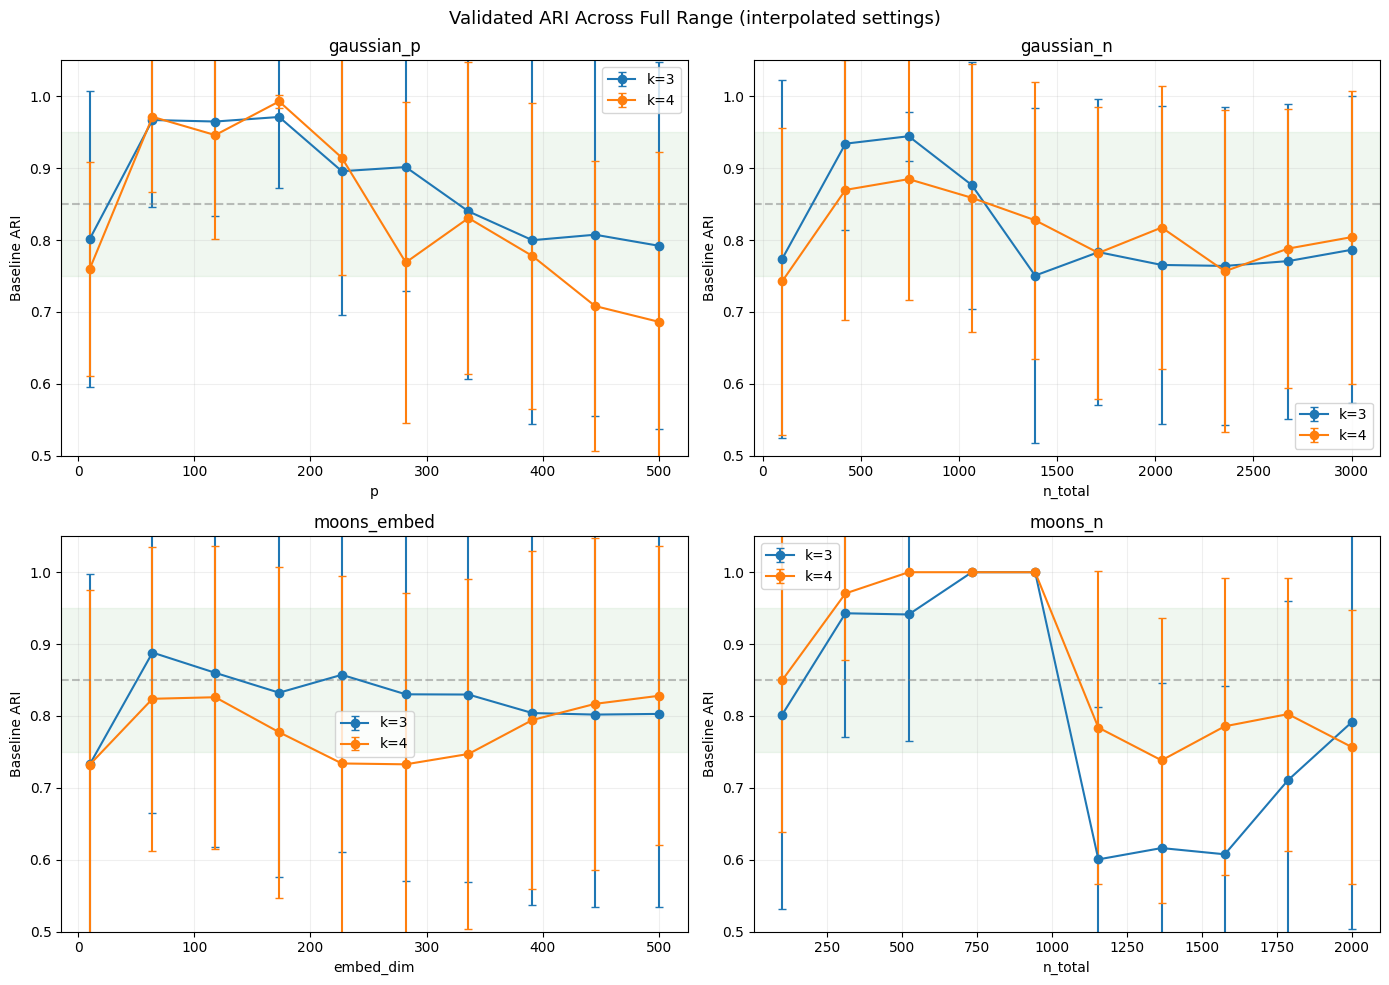

In [45]:
# ── Plot validation curves ──

fig, axes_val = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Validated ARI Across Full Range (interpolated settings)", fontsize=13)

for idx, bench_name in enumerate(BENCH_CONFIGS):
    ax = axes_val.flat[idx]
    ax.set_title(bench_name)
    ax.set_xlabel(BENCH_CONFIGS[bench_name]["axis_name"])
    ax.set_ylabel("Baseline ARI")

    for true_k in TRUE_KS:
        curve = validation_curves[(bench_name, true_k)]
        xs = [c[0] for c in curve]
        ys = [c[1] for c in curve]
        es = [c[2] for c in curve]
        ax.errorbar(xs, ys, yerr=es, fmt="o-", capsize=3, label=f"k={true_k}")

    ax.axhline(0.85, color="gray", ls="--", alpha=0.5)
    ax.axhspan(0.75, 0.95, alpha=0.06, color="green")
    ax.set_ylim(0.5, 1.05)
    ax.legend()
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

## B5) Final Scaling Settings

In [46]:
SCALING_VAR_NAMES = {
    "gaussian_p": (
        "settings_by_k_gaussians_dimensionality",
        "other_settings_gaussians_dimensionality",
    ),
    "gaussian_n": (
        "settings_by_k_gaussians_samples",
        "other_settings_gaussians_samples",
    ),
    "moons_embed": (
        "settings_by_k_moons_dimensionality",
        "other_settings_moons_dimensionality",
    ),
    "moons_n": ("settings_by_k_moons_samples", "other_settings_moons_samples"),
}

for bench_name, bench_config in BENCH_CONFIGS.items():
    settings_var, other_var = SCALING_VAR_NAMES[bench_name]
    print(f"# ── {bench_name} ──")
    print(f"{settings_var} = {{")
    for true_k in TRUE_KS:
        print(f"    {true_k}: {{")
        for anchor_name in ANCHOR_NAMES:
            r = scaling_results[(bench_name, true_k, anchor_name)]
            print(f'        "{anchor_name}": {{')
            print(f'            "cluster_scale": {r["cluster_scale"]},')
            if "embed_param" in r:
                print(f'            "embed_param": {r["embed_param"]},')
            print(
                f"        }},  # ARI={r['search_ari']:.3f} at {bench_config['axis_name']}={r['axis_value']}"
            )
        print("    },")
    print("}")
    print()
    print(f"{other_var} = {{")
    for k2, v2 in bench_config["base_sim_kwargs"].items():
        print(f'    "{k2}": {repr(v2)},')
    print("}")
    print()

print("\nLinear ranges for benchmark_scaling():")
for bench_name in BENCH_CONFIGS:
    rng = SCALING_RANGES[bench_name]
    axis = BENCH_CONFIGS[bench_name]["axis_name"]
    x_values = np.linspace(rng["min"], rng["max"], GRANULARITY).astype(int).tolist()
    print(
        f"  {bench_name} ({axis}): np.linspace({rng['min']}, {rng['max']}, num=granularity)"
    )
    print(f"    -> {x_values}")

# ── gaussian_p ──
settings_by_k_gaussians_dimensionality = {
    3: {
        "start": {
            "cluster_scale": [2.23, 2.23, 2.23],
        },  # ARI=0.866 at p=10
        "middle": {
            "cluster_scale": [7.23, 7.23, 7.23],
        },  # ARI=0.831 at p=255
        "end": {
            "cluster_scale": [8.73, 8.73, 8.73],
        },  # ARI=0.850 at p=500
    },
    4: {
        "start": {
            "cluster_scale": [2.28, 2.28, 2.28, 2.28],
        },  # ARI=0.832 at p=10
        "middle": {
            "cluster_scale": [6.84, 6.84, 6.84, 6.84],
        },  # ARI=0.843 at p=255
        "end": {
            "cluster_scale": [8.62, 8.62, 8.62, 8.62],
        },  # ARI=0.833 at p=500
    },
}

other_settings_gaussians_dimensionality = {
    "n_total": 500,
    "corr_type": 'ar1',
    "corr_strength": 0.5,
    "cluster_size_dirichlet_alpha": 0.5,
}

# ── gaussian_n ──
settings_by_k_gaussians_samples = {
    3: {
        "start": {
            "cluster_scale": [3.39, 3.39, 

---
# Auto-Inject into Benchmarking.ipynb (Optional)

Run the preview first to verify, then uncomment the apply cell.

In [47]:
nb_path = Path.cwd() / "Benchmarking.ipynb"

# Cell indices (0-indexed) in Benchmarking.ipynb
DIFFICULTY_CELL_MAP = {
    "circles": 34,
    "moons": 41,
    "swiss_roll": 48,
}
SCALING_CELL_MAP = {
    "gaussian_p": 56,
    "gaussian_n": 61,
    "moons_embed": 67,
    "moons_n": 72,
}


def _build_scaling_cell_code(bench_name):
    bench_config = BENCH_CONFIGS[bench_name]
    settings_var, other_var = SCALING_VAR_NAMES[bench_name]

    lines = [f"{settings_var} = {{"]
    for true_k in TRUE_KS:
        lines.append(f"    {true_k}: {{")
        for anchor_name in ANCHOR_NAMES:
            r = scaling_results[(bench_name, true_k, anchor_name)]
            lines.append(f'        "{anchor_name}": {{')
            lines.append(f'            "cluster_scale": {r["cluster_scale"]},')
            if "embed_param" in r:
                lines.append(f'            "embed_param": {r["embed_param"]},')
            lines.append(f"        }},")
        lines.append("    },")
    lines.append("}")
    lines.append(f"")
    lines.append(f"{other_var} = {{")
    for k2, v2 in bench_config["base_sim_kwargs"].items():
        lines.append(f'    "{k2}": {repr(v2)},')
    lines.append("}")
    return "\n".join(lines)


def inject_all_settings(dry_run=True):
    with open(nb_path, "r") as f:
        nb = json.load(f)

    # Difficulty cells
    for regime_name, cell_idx in DIFFICULTY_CELL_MAP.items():
        new_code = _fmt_difficulty_settings(regime_name)
        old_source = "".join(nb["cells"][cell_idx]["source"])
        if dry_run:
            print(f"Cell {cell_idx} ({regime_name}):")
            print(f"  OLD: {old_source[:80].strip()}...")
            print(f"  NEW: {new_code[:80].strip()}...")
            print()
        else:
            source_lines = [line + "\n" for line in new_code.split("\n")]
            if source_lines:
                source_lines[-1] = source_lines[-1].rstrip("\n")
            nb["cells"][cell_idx]["source"] = source_lines
            nb["cells"][cell_idx]["outputs"] = []
            nb["cells"][cell_idx]["execution_count"] = None

    # Scaling cells
    for bench_name, cell_idx in SCALING_CELL_MAP.items():
        new_code = _build_scaling_cell_code(bench_name)
        old_source = "".join(nb["cells"][cell_idx]["source"])
        if dry_run:
            print(f"Cell {cell_idx} ({bench_name}):")
            print(f"  OLD: {old_source[:80].strip()}...")
            print(f"  NEW: {new_code[:80].strip()}...")
            print()
        else:
            source_lines = [line + "\n" for line in new_code.split("\n")]
            if source_lines:
                source_lines[-1] = source_lines[-1].rstrip("\n")
            nb["cells"][cell_idx]["source"] = source_lines
            nb["cells"][cell_idx]["outputs"] = []
            nb["cells"][cell_idx]["execution_count"] = None

    if not dry_run:
        backup_path = nb_path.with_suffix(".ipynb.bak")
        shutil.copy2(nb_path, backup_path)
        print(f"Backup saved to: {backup_path}")
        with open(nb_path, "w") as f:
            json.dump(nb, f, indent=1, ensure_ascii=False)
            f.write("\n")
        print(f"Updated {nb_path}")


# Preview:
inject_all_settings(dry_run=True)

Cell 34 (circles):
  OLD: settings_by_k_circles = {
    3: {
        "easy": {
            "cluster_scale"...
  NEW: settings_by_k_circles = {
    3: {
        "easy": {
            "cluster_scale"...

Cell 41 (moons):
  OLD: settings_by_k_moons = {
    3: {
        "easy": {
            "cluster_scale":...
  NEW: settings_by_k_moons = {
    3: {
        "easy": {
            "cluster_scale":...

Cell 48 (swiss_roll):
  OLD: settings_by_k_swiss_rolls = {
    3: {
        "easy": {
            "cluster_sc...
  NEW: settings_by_k_swiss_rolls = {
    3: {
        "easy": {
            "cluster_sc...

Cell 56 (gaussian_p):
  OLD: settings_by_k_gaussians_dimensionality = {
    3: {
        "start": {"cluster_s...
  NEW: settings_by_k_gaussians_dimensionality = {
    3: {
        "start": {...

Cell 61 (gaussian_n):
  OLD: settings_by_k_gaussians_samples = {
    3: {
        "start": {"cluster_scale":...
  NEW: settings_by_k_gaussians_samples = {
    3: {
        "start": {
            "clu.

In [48]:
# Uncomment and run to apply:
# inject_all_settings(dry_run=False)